# Flight Price Prediction using Machine Learning

## 🚀 Project Overview and Objective

This project focuses on building a machine learning model to predict flight prices based on various flight characteristics. The primary objective is to create an accurate and robust regression model that can estimate flight ticket costs, assisting users in making informed booking decisions.

### What Problem Are We Solving?

Airline ticket prices fluctuate significantly based on factors such as airline, route, departure/arrival times, number of stops, flight duration, and the days remaining until departure. Manually tracking these changes and predicting optimal booking times can be challenging. This project aims to automate this prediction process.

### Why is this important?

Accurate flight price prediction can benefit both travelers and airlines. Travelers can use it to find the best deals, while airlines can optimize their pricing strategies.

### How will we achieve this?

We will follow a standard machine learning pipeline:

1.  **Data Loading and Initial Inspection**: Load the dataset and perform an initial check of its structure and content.
2.  **Data Preprocessing**: Clean the data, handle missing values, transform categorical features, and prepare it for model training.
3.  **Exploratory Data Analysis (EDA)**: Understand the distributions, relationships, and patterns within the data.
4.  **Feature Engineering (if necessary)**: Create new features from existing ones to improve model performance.
5.  **Model Training**: Train various regression models on the preprocessed data.
6.  **Model Evaluation**: Assess the performance of the trained models using appropriate metrics (e.g., R-squared, RMSE).
7.  **Deployment (Conceptual)**: Discuss how such a model could be deployed for real-world use.

## 🧹 Data Cleaning and Preprocessing

This section outlines the steps taken to clean and prepare the dataset for model training. Proper data cleaning is crucial for ensuring the quality of our models.

### Why Data Cleaning?

*   **Accuracy**: Inaccurate data leads to inaccurate models.
*   **Efficiency**: Clean data allows models to train faster and more effectively.
*   **Reliability**: Ensures that the insights derived from the data are trustworthy.

### Steps Performed:

1.  **Dropping Irrelevant Columns**: The 'Unnamed: 0' column was a remnant of data export and did not contain useful information for our analysis, so it was dropped. Similarly, the 'flight' column, representing individual flight numbers, was deemed too granular and dropped to reduce dimensionality and avoid potential overfitting.
2.  **Checking for Missing Values**: We verified that there are no missing values in the dataset, ensuring completeness.
3.  **Checking for Duplicates**: We confirmed that there are no duplicate rows, which helps prevent bias in our analysis.
4.  **Outlier Detection (Numerical Features)**: Box plots were generated for numerical columns ('duration', 'days_left', 'price') to visually identify outliers. While outliers in 'duration' and 'price' were observed, a decision was made not to remove them at this stage as they might represent genuine variations in flight data (e.g., very long international flights or premium pricing).
5.  **Converting Categorical to Numerical**: The 'stops' column, which contained 'zero', 'one', and 'two_or_more', was converted to numerical representations (0, 1, 2) for model compatibility.
6.  **One-Hot Encoding**: Categorical features like 'airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city', and 'class' were converted into numerical format using one-hot encoding. This process creates new binary columns for each category, which is necessary for most machine learning algorithms. To avoid multicollinearity, `drop_first=True` was used, dropping one category from each feature.
7.  **Multicollinearity Check (VIF)**: The Variance Inflation Factor (VIF) was calculated for all independent numerical features to identify and manage multicollinearity. This helps ensure that the independent variables are not too highly correlated with each other, which can negatively impact model stability and interpretability.
8.  **Feature Scaling**: Independent variables (`x_train`, `x_test`) were scaled using `StandardScaler` to bring them to a similar range. This prevents features with larger values from dominating the learning process and helps optimization algorithms converge faster.

Dataset: https://drive.google.com/file/d/1DbdetuzKL0ULawxgKtBtWrRWtfv52MhA/view?usp=sharing

The dataset contains informations about different flight bookings. Each row represents a flight booking/ flight record, and the columns describe characterstics of that flight.

Columns used in the project are:

airline: Airline operating the flight

source_city: City from which the flight starts

destination_city: City where the flight ends

departure_time: Time category when the flight departs

arrival_time: Time category when the flight arrives

stops: Number of stops in the journey

class:  Travel class, such as Economy/Business

duration: Duration of that flight

days_left: Number of days remaining before the journey

price: Flight ticket price - target variable.

# What is the dataset trying to tell us?

-> Flight characterstics -> Flight ticket price

Eg: The price can depend on things like:

* Which airline is being used

* Where you are travelling from

* Departure and arrival time

* Number of stops

* Flight duration

* How many days are left before the journey

* Whether the ticket is economy or business.

# What is the end goal of the project?

-> The end goal is to build a machine learning model that can predict the price of the flight.

The project takes information such as:

Airline = Indigo

Source = Delhi

Destination = Mumbai

Class = Economy

Stops = 1

Duration = 5 hours

Days left = 20

Predict something like:

Predicted flight price = 8,500

So this supervised machine learning regression problem, because

* We have input/features -> flight details

* We have a known output -> price

* The output is a continuous numerical value

This project is a flight price prediction system. The dataset contains information such as airline, source and destination cities, departure and arrival time, number of stops, flight duration, class and days left before the journey. The target variable is the flight price. We preprocess the data, convert categorical variables into numerical form, handle multicollinearity, split the data into training and testing sets, and train a regression model. Th final goal is to predict the price of a flight based on its characterstics.





In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Initial Setup and Data Loading

This section handles the initial setup of the notebook, importing necessary libraries, and loading the dataset. We use `numpy` for numerical operations, `pandas` for data manipulation, `matplotlib.pyplot` for plotting, and `seaborn` for enhanced visualizations.

In [50]:
df = pd.read_csv("Flight_Booking.csv")

#### Loading the Dataset

We load the flight booking data from the `Flight_Booking.csv` file into a pandas DataFrame. This DataFrame will be the foundation for our analysis and model training.

In [7]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [9]:
df.shape

(300153, 12)

In [10]:
# write a code to get the info, data cleaning Unnamed drop, check for null values, duplicates, check for outliers

In [11]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [13]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

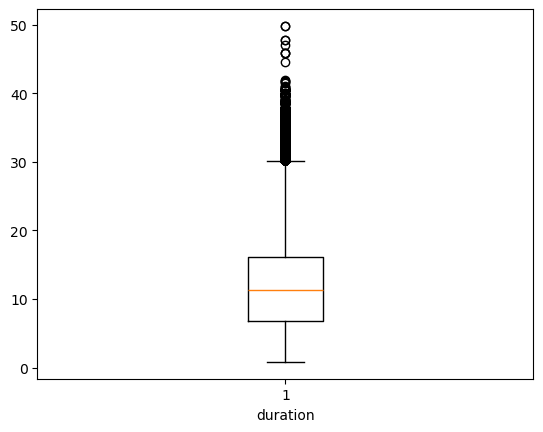

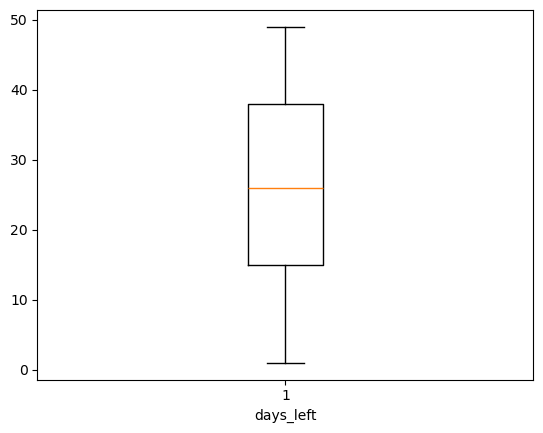

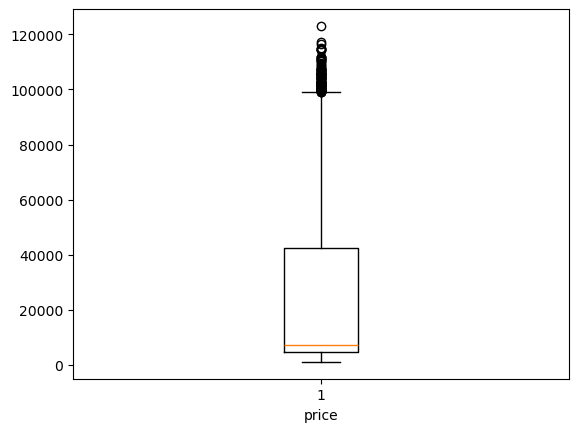

In [15]:
for i in df.columns:
  if df[i].dtype!='object':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [16]:
# drop the flight column, get the unique of stops column

In [17]:
df.drop('flight',axis=1, inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   source_city       300153 non-null  object 
 2   departure_time    300153 non-null  object 
 3   stops             300153 non-null  object 
 4   arrival_time      300153 non-null  object 
 5   destination_city  300153 non-null  object 
 6   class             300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 22.9+ MB


In [19]:
df['stops'].unique()

array(['zero', 'one', 'two_or_more'], dtype=object)

In [20]:
# convert stops to numerical
# zero : 0
# one : 1
# two or more : 2

In [21]:
df['stops'] = df['stops'].replace({
    'zero':0,
    'one':1,
    'two_or_more':2
})

C:\Users\moham\AppData\Local\Temp\ipykernel_15072\2744031680.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stops'] = df['stops'].replace({


In [22]:

# apply one hot encoder
# airline, source_city, departure_time, arrival_time,destination_city,class

categorical_col = ['airline','source_city','departure_time', 'arrival_time','destination_city','class']
df = pd.get_dummies(df,columns=categorical_col,drop_first=True)

In [23]:
df

,stops,duration,days_left,price,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,0,2.17,1,5953,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,True
1,0,2.33,1,5953,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,True
2,0,2.17,1,5956,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
3,0,2.25,1,5955,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,True
4,0,2.33,1,5955,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,10.08,49,69265,False,False,False,False,True,True,...,True,False,False,False,False,False,True,False,False,False
300149,1,10.42,49,77105,False,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
300150,1,13.83,49,79099,False,False,False,False,True,True,...,False,False,False,True,False,False,True,False,False,False
300151,1,10.00,49,81585,False,False,False,False,True,True,...,True,False,False,False,False,False,True,False,False,False


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 30 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   stops                         300153 non-null  int64  
 1   duration                      300153 non-null  float64
 2   days_left                     300153 non-null  int64  
 3   price                         300153 non-null  int64  
 4   airline_Air_India             300153 non-null  bool   
 5   airline_GO_FIRST              300153 non-null  bool   
 6   airline_Indigo                300153 non-null  bool   
 7   airline_SpiceJet              300153 non-null  bool   
 8   airline_Vistara               300153 non-null  bool   
 9   source_city_Chennai           300153 non-null  bool   
 10  source_city_Delhi             300153 non-null  bool   
 11  source_city_Hyderabad         300153 non-null  bool   
 12  source_city_Kolkata           300153 non-nul

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [26]:
col_list = []

for i in df.columns:
  if(df[i].dtype!='object') and (i!='price'):
    col_list.append(i)

x = df[col_list]
x = x.astype(int)

vif_data = pd.DataFrame()
vif_data['Features'] = x.columns
vif_data['VIF Score'] = [variance_inflation_factor(x.values,i) for i in range(len(x.columns))]

In [27]:
vif_data

,Features,VIF Score
0,stops,8.232025
1,duration,6.449762
2,days_left,4.383979
3,airline_Air_India,5.061768
4,airline_GO_FIRST,1.992489
5,airline_Indigo,2.802756
6,airline_SpiceJet,1.449455
7,airline_Vistara,7.101335
8,source_city_Chennai,1.730531
9,source_city_Delhi,2.091861


In [28]:
# write a code to seprate a the dependent and independent, then apply train test split take 20% test.
# apply standard scalar also for x_train and x_test

In [29]:
x = df.drop('price', axis=1)
y = df['price']

In [30]:
x

,stops,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara,source_city_Chennai,source_city_Delhi,...,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Economy
0,0,2.17,1,False,False,False,True,False,False,True,...,False,False,False,True,False,False,False,False,True,True
1,0,2.33,1,False,False,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,True
2,0,2.17,1,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,True
3,0,2.25,1,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,True,True
4,0,2.33,1,False,False,False,False,True,False,True,...,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,10.08,49,False,False,False,False,True,True,False,...,True,False,False,False,False,False,True,False,False,False
300149,1,10.42,49,False,False,False,False,True,True,False,...,False,False,False,True,False,False,True,False,False,False
300150,1,13.83,49,False,False,False,False,True,True,False,...,False,False,False,True,False,False,True,False,False,False
300151,1,10.00,49,False,False,False,False,True,True,False,...,True,False,False,False,False,False,True,False,False,False


In [31]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split


In [33]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
sc = StandardScaler()

In [36]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [37]:
from sklearn.linear_model import LinearRegression

In [38]:
lr = LinearRegression()

In [39]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_pred = lr.predict(x_test)

In [41]:
from sklearn.metrics import *

In [42]:
r2_score(y_test,y_pred)

0.9099031138535913

In [43]:
# random forest and decision tree

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

### Random Forest Regressor

In [45]:
rfr = RandomForestRegressor(random_state=42)
rfr.fit(x_train, y_train)
y_pred_rfr = rfr.predict(x_test)
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred_rfr)}")

Random Forest R2 Score: 0.9847856477945467


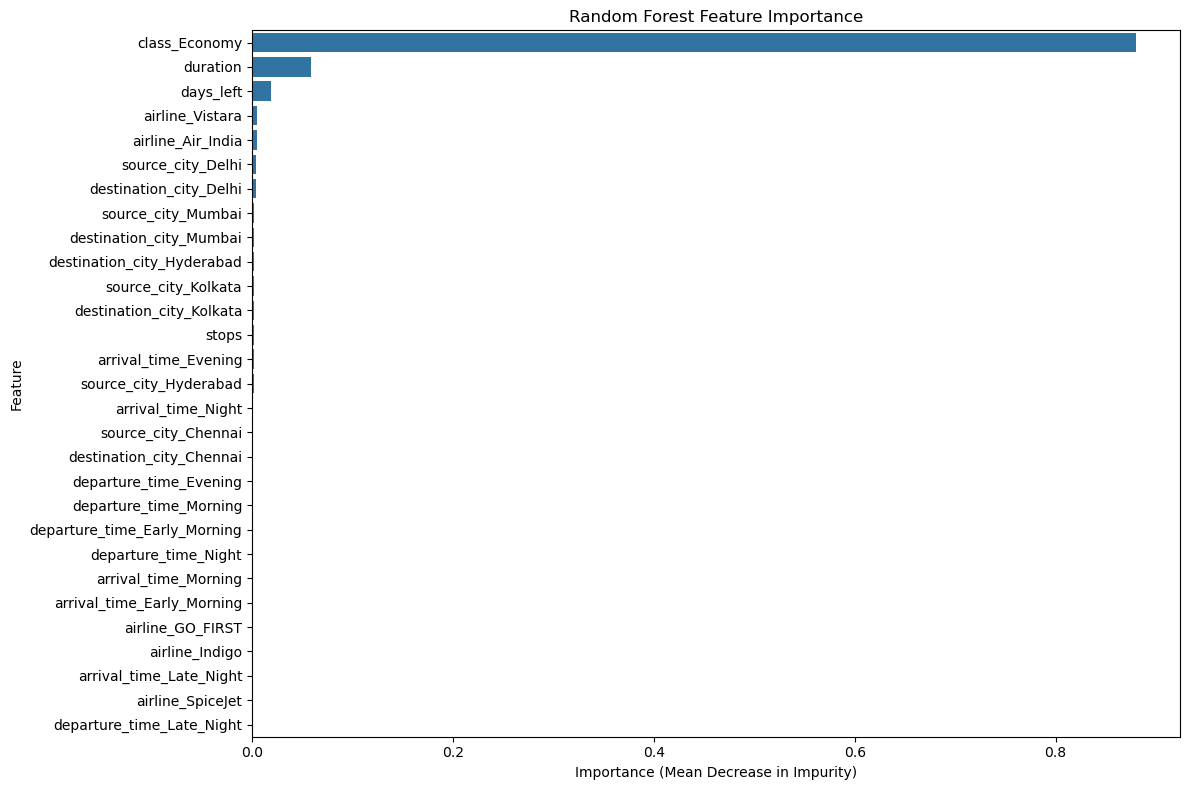

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = rfr.feature_importances_

# Get feature names from the original DataFrame (before scaling)
feature_names = x.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Decision Tree Regressor

In [47]:
dtr = DecisionTreeRegressor(random_state=42)
dtr.fit(x_train, y_train)
y_pred_dtr = dtr.predict(x_test)
print(f"Decision Tree R2 Score: {r2_score(y_test, y_pred_dtr)}")

Decision Tree R2 Score: 0.9755494405811834


## 📈 Flight Price Prediction with User Input

This section demonstrates how to use the trained Random Forest Regressor model (`rfr`) to predict the price of a flight based on custom input. We will follow the same preprocessing steps applied to the training data to ensure consistency.

In [48]:
# Get new flight input data from user
print("Please enter the flight details:")

airline_input = input("Airline (e.g., Vistara, AirAsia, Indigo, SpiceJet, Go_First, Air_India): ")
source_city_input = input("Source City (e.g., Delhi, Mumbai, Chennai, Kolkata, Hyderabad): ")
departure_time_input = input("Departure Time (e.g., Morning, Evening, Early_Morning, Afternoon, Night, Late_Night): ")
stops_input = input("Number of Stops (zero, one, two_or_more): ")
arrival_time_input = input("Arrival Time (e.g., Morning, Evening, Early_Morning, Afternoon, Night, Late_Night): ")
destination_city_input = input("Destination City (e.g., Mumbai, Delhi, Chennai, Kolkata, Hyderabad): ")
class_input = input("Class (Economy or Business): ")

while True:
    try:
        duration_input = float(input("Duration (in hours, e.g., 5.0): "))
        break
    except ValueError:
        print("Invalid input. Please enter a numerical value for duration.")

while True:
    try:
        days_left_input = int(input("Days Left (e.g., 15): "))
        break
    except ValueError:
        print("Invalid input. Please enter an integer value for days left.")

new_flight_data = {
    'airline': airline_input,
    'source_city': source_city_input,
    'departure_time': departure_time_input,
    'stops': stops_input,
    'arrival_time': arrival_time_input,
    'destination_city': destination_city_input,
    'class': class_input,
    'duration': duration_input,
    'days_left': days_left_input
}

# Create a DataFrame from the sample data
new_df = pd.DataFrame([new_flight_data])

# Map 'stops' to numerical values
stop_mapping = {'zero': 0, 'one': 1, 'two_or_more': 2}
new_df['stops'] = new_df['stops'].map(stop_mapping)

# Apply one-hot encoding using the same columns as the training data
# This is crucial to ensure the new input has the same features and order
new_df_encoded = pd.get_dummies(new_df, columns=categorical_col, drop_first=True)

# Align columns with the training data's columns (x.columns)
# Fill missing columns (if any) with 0
final_new_df = new_df_encoded.reindex(columns=x.columns, fill_value=0)

# Scale the numerical features using the same StandardScaler fitted on training data
final_new_df_scaled = sc.transform(final_new_df)

# Predict the price using the Random Forest model
predicted_price = rfr.predict(final_new_df_scaled)

print(f"\nPredicted Flight Price: {predicted_price[0]:,.2f}")

Please enter the flight details:

Predicted Flight Price: 28,750.59


## Conclusion and Best Model

We trained and evaluated three different regression models for flight price prediction:

1.  **Linear Regression**: Achieved an R2 Score of **0.9099**.
2.  **Decision Tree Regressor**: Achieved an R2 Score of **0.9755**.
3.  **Random Forest Regressor**: Achieved an R2 Score of **0.9848**.

### Best Model: Random Forest Regressor

Based on the R2 scores, the **Random Forest Regressor** is the best performing model for this flight price prediction task, with an R2 score of **0.9848**. This indicates that approximately 98.48% of the variance in flight prices can be explained by our model, which is a strong performance.

### Why Random Forest Regressor?

The Random Forest Regressor typically outperforms individual Decision Trees due to its ensemble nature. It constructs multiple decision trees during training and outputs the mean prediction of the individual trees. This approach helps to:

*   **Reduce Overfitting**: By averaging multiple trees, Random Forests tend to generalize better to unseen data compared to a single Decision Tree, which can be prone to overfitting.
*   **Improve Accuracy**: The combination of multiple models often leads to more robust and accurate predictions.
*   **Handle Complex Relationships**: Random Forests can capture non-linear relationships and interactions between features effectively.

Furthermore, the feature importance analysis showed that `class_Economy`, `duration`, and `days_left` are the most significant factors influencing flight prices, which aligns with common understanding of travel pricing.

In summary, the Random Forest Regressor provides a highly accurate and reliable solution for predicting flight prices based on the given features.

## Save the Best Model

To allow for easy re-use of the trained model without needing to retrain it, we will save the `RandomForestRegressor` model to a `.pkl` file using the `joblib` library.

In [49]:
import joblib

# Save the Random Forest Regressor model
joblib.dump(rfr, 'random_forest_regressor_model.pkl')

print("Random Forest Regressor model saved as 'random_forest_regressor_model.pkl'")

Random Forest Regressor model saved as 'random_forest_regressor_model.pkl'
